# Hierarchical Insect Classifier — Ablation Run C (No Coherence Loss)

> **Run C**: `HierarchicalCoherenceLoss` is removed from all 4 parent→child pairs.
> All other losses (CE on every head, LeafBranchFocalLoss on l4a, sibling consistency)
> are **unchanged**.

CSV facts (hierarchical_labels_v15.csv)
| Property | Value |
|---|---|
| Total samples | 37,588 (train 28,466 / val 7,120 / test 2,002) |
| Species present | 1-3, 5-12, 14-18, 21-31 |
| l1_pest | 0=non-pest, 1=pest |
| l2_role | 0=predator, 1=non-predator, -1=masked |
| l3_pred_type | 0=ladybug-pred, 1=other-pred, -1=masked |
| l3_nonpred_type | 0=ladybug-nonpred, 1=other-nonpred, -1=masked |
| sp_pred_ladybug_common | 0-10 → sp1-3,5-12 (11 classes), -1=masked |
| sp_other_pred | 0-2 → sp14-16 (3 classes), -1=masked |
| sp_nonpred_ladybug | 0-1 → sp17-18 (2 classes), -1=masked |

## Hierarchy
```
level1 (pest/non-pest)
├── 0 → sp21 (non-pest, terminal)
└── 1 → level2 (predator role)
    ├── 0 (predator) → l3a (pred type)
    │   ├── 0 (ladybug-pred) → l4a: 11 classes → sp1,2,3,5,6,7,8,9,10,11,12
    │   └── 1 (other-pred)   → l4b:  3 classes → sp14,15,16
    └── 1 (non-predator) → l3b (nonpred type)
        ├── 0 (ladybug-nonpred) → l4c: 2 classes → sp17,18
        └── 1 (other-nonpred)   → sp22-31 (terminal, merged as sp22

In [1]:
!pip install timm scikit-learn pandas pillow tqdm -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


## 1. Dataset

In [2]:
# Cell 2 — Dataset
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class HierarchicalInsectDataset(Dataset):
    EXCLUDED_SPECIES = {4, 13, 19}

    def __init__(self, csv_file, split, img_size=224):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        self.df = self.df[~self.df["species_id"].isin(self.EXCLUDED_SPECIES)].reset_index(drop=True)
        self.split = split

        # No augmentation — identical transform for all splits
        self.transform = transforms.Compose([
            transforms.Resize(int(img_size * 256 / 224)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        labels = {
            "level1":     torch.tensor(row["l1_pest"],                 dtype=torch.long),
            "level2":     torch.tensor(row["l2_role"],                 dtype=torch.long),
            "l3a":        torch.tensor(row["l3_pred_type"],            dtype=torch.long),
            "l3b":        torch.tensor(row["l3_nonpred_type"],         dtype=torch.long),
            "l4a":        torch.tensor(row["sp_pred_ladybug_common"],  dtype=torch.long),
            "l4b":        torch.tensor(row["sp_other_pred"],           dtype=torch.long),
            "l4c":        torch.tensor(row["sp_nonpred_ladybug"],      dtype=torch.long),
            "species_id": torch.tensor(row["species_id"],              dtype=torch.long),
        }
        return img, labels

## 2. Model

In [3]:
# Cell 3 — Model
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class StableAdapter(nn.Module):
    def __init__(self, dim, bottleneck=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, bottleneck),
            nn.LayerNorm(bottleneck),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(bottleneck, dim),
            nn.Dropout(dropout),
        )
        self.gate = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return x + self.gate * self.net(x)


class EfficientNetHierarchicalV5(nn.Module):
    def __init__(self, backbone="efficientnet_b0", pretrained=True, feat_dim=512):
        super().__init__()

        self.backbone = timm.create_model(
            backbone,
            pretrained=pretrained,
            num_classes=0,
            drop_rate=0.2,
            drop_path_rate=0.3,
        )
        in_features = self.backbone.num_features  # 1280 for B0

        self.shared = nn.Sequential(
            nn.Linear(in_features, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        for layer in self.shared:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

        self.adapt_l1  = StableAdapter(feat_dim)
        self.adapt_l2  = StableAdapter(feat_dim)
        self.adapt_l3a = StableAdapter(feat_dim)
        self.adapt_l3b = StableAdapter(feat_dim)
        self.adapt_l4b = StableAdapter(feat_dim)
        self.adapt_l4c = StableAdapter(feat_dim)
        self.adapt_l4a = StableAdapter(feat_dim, bottleneck=128, dropout=0.4)

        self.head_level1 = nn.Linear(feat_dim, 2)
        self.head_level2 = nn.Linear(feat_dim, 2)
        self.head_l3a    = nn.Linear(feat_dim, 2)
        self.head_l3b    = nn.Linear(feat_dim, 2)
        self.head_l4a    = nn.Linear(feat_dim, 12)
        self.head_l4b    = nn.Linear(feat_dim, 3)
        self.head_l4c    = nn.Linear(feat_dim, 2)

        for head in [self.head_level1, self.head_level2, self.head_l3a,
                     self.head_l3b, self.head_l4a, self.head_l4b, self.head_l4c]:
            nn.init.xavier_normal_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, x, targets=None):
        feats = self.shared(self.backbone(x))
        outputs = {}
        outputs["level1"] = self.head_level1(self.adapt_l1(feats))
        outputs["level2"] = self.head_level2(self.adapt_l2(feats))
        outputs["l3a"]    = self.head_l3a(self.adapt_l3a(feats))
        outputs["l3b"]    = self.head_l3b(self.adapt_l3b(feats))
        outputs["l4a"]    = self.head_l4a(self.adapt_l4a(feats))
        outputs["l4b"]    = self.head_l4b(self.adapt_l4b(feats))
        outputs["l4c"]    = self.head_l4c(self.adapt_l4c(feats))
        return outputs

## 3. Loss

In [4]:
# Cell 4 — Loss  |  Ablation Run C: NO HierarchicalCoherenceLoss
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class LeafBranchFocalLoss(nn.Module):
    def __init__(self, num_classes=12, alpha=0.25, gamma=4.0, ignore_index=-1):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, logits, targets):
        valid = targets != self.ignore_index
        if valid.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits = logits[valid]
        targets = targets[valid]
        targets_one_hot = F.one_hot(targets, num_classes=self.num_classes).float()
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.clamp(torch.exp(log_probs), min=self.eps, max=1.0 - self.eps)
        ce_loss = -targets_one_hot * log_probs
        p_t = torch.clamp((probs * targets_one_hot).sum(dim=1), min=self.eps, max=1.0 - self.eps)
        focal_weight = (1 - p_t) ** self.gamma
        return (self.alpha * focal_weight * ce_loss.sum(dim=1)).mean()


class LeafSiblingConsistencyLoss(nn.Module):
    def __init__(self, weight=0.05, similarity_threshold=0.7):
        super().__init__()
        self.weight = weight
        self.similarity_threshold = similarity_threshold

    def forward(self, leaf_logits, sibling_mask=None):
        probs = F.softmax(leaf_logits, dim=1)
        if sibling_mask is None:
            entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
            return self.weight * entropy.mean()
        batch_size = probs.size(0)
        probs_expanded1 = probs.unsqueeze(2)
        probs_expanded2 = probs.unsqueeze(1)
        diff = torch.abs(probs_expanded1 - probs_expanded2)
        sibling_mask = sibling_mask.unsqueeze(0).expand(batch_size, -1, -1)
        sibling_diff = diff * sibling_mask
        loss = F.relu(sibling_diff - self.similarity_threshold).mean()
        return self.weight * loss


class StableClassBalancedFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.999, gamma_minor=2.0,
                 gamma_major=0.5, ignore_index=-1):
        super().__init__()
        samples_per_class = torch.tensor(samples_per_class, dtype=torch.float)
        effective_num = 1.0 - torch.pow(beta, samples_per_class)
        effective_num = torch.clamp(effective_num, min=1e-8)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum()
        self.register_buffer("alpha", weights)
        self.gamma_minor = gamma_minor
        self.gamma_major = gamma_major
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, logits, targets):
        valid = targets != self.ignore_index
        if valid.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits = logits[valid]
        targets = targets[valid]
        log_probs = F.log_softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        pt = torch.clamp((torch.exp(log_probs) * targets_one_hot).sum(dim=1),
                         min=self.eps, max=1.0 - self.eps)
        gamma = torch.where(targets == 1,
                            torch.full_like(pt, self.gamma_minor),
                            torch.full_like(pt, self.gamma_major))
        alpha = self.alpha.to(targets.device)[targets]
        return (-alpha * (1.0 - pt) ** gamma * torch.log(pt)).mean()


class CardinalityWeightedCELoss(nn.Module):
    def __init__(self, num_classes, ignore_index=-1, label_smoothing=0.1):
        super().__init__()
        self.scale = 1.0 / (num_classes ** 0.5)
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index,
                                      label_smoothing=label_smoothing)

    def forward(self, logits, targets):
        return self.scale * self.ce(logits, targets)


# ── Run C: HierarchicalCoherenceLoss intentionally removed ──


class HierarchicalMultiTaskLoss(nn.Module):
    """Run C: HierarchicalCoherenceLoss removed. All 4 coherence pairs disabled."""
    def __init__(self, level1_samples, lambda_coherence=0.1,
                 leaf_lambda=0.3, use_leaf_consistency=True):
        super().__init__()

        self.loss_level1    = StableClassBalancedFocalLoss(level1_samples)
        self.loss_level2    = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3a       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3b       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l4a_ce    = CardinalityWeightedCELoss(12, label_smoothing=0.1)
        self.loss_l4a_focal = LeafBranchFocalLoss(num_classes=12, alpha=0.25, gamma=4.0)
        self.loss_l4b       = CardinalityWeightedCELoss(3,  label_smoothing=0.1)
        self.loss_l4c       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)

        self.use_leaf_consistency = use_leaf_consistency
        if use_leaf_consistency:
            self.leaf_consistency = LeafSiblingConsistencyLoss(weight=0.05)

        # ── Run C: self.coherence intentionally removed ──

        self.task_weights = {
            "level1":    1.0,
            "level2":    0.8,
            "l3a":       0.6,
            "l3b":       0.6,
            "l4a_ce":    0.6,
            "l4a_focal": 0.4,
            "l4b":       0.4,
            "l4c":       0.4,
        }
        self.leaf_lambda = leaf_lambda

    def forward(self, outputs, targets, sibling_mask=None):
        device = next(iter(outputs.values())).device
        total_loss = torch.tensor(0.0, device=device, requires_grad=True)
        loss_components = {}

        l1_loss = self.loss_level1(outputs["level1"], targets["level1"])
        if torch.isfinite(l1_loss):
            total_loss = total_loss + self.task_weights["level1"] * l1_loss
            loss_components["l1"] = l1_loss.item()

        non_pest = targets["level1"] == 0

        def gate(t):
            t = t.clone()
            t[non_pest] = -1
            return t

        t2  = gate(targets["level2"])
        t3a = gate(targets["l3a"])
        t3b = gate(targets["l3b"])
        t4a = gate(targets["l4a"])
        t4b = gate(targets["l4b"])
        t4c = gate(targets["l4c"])

        losses = [
            ("level2",    self.loss_level2(outputs["level2"], t2)),
            ("l3a",       self.loss_l3a(outputs["l3a"], t3a)),
            ("l3b",       self.loss_l3b(outputs["l3b"], t3b)),
            ("l4a_ce",    self.loss_l4a_ce(outputs["l4a"], t4a)),
            ("l4a_focal", self.loss_l4a_focal(outputs["l4a"], t4a)),
            ("l4b",       self.loss_l4b(outputs["l4b"], t4b)),
            ("l4c",       self.loss_l4c(outputs["l4c"], t4c)),
        ]

        for task_name, loss_val in losses:
            if torch.isfinite(loss_val):
                total_loss = total_loss + self.task_weights[task_name] * loss_val
                loss_components[task_name] = loss_val.item()

        if self.use_leaf_consistency and "l4a" in outputs:
            lc = self.leaf_consistency(outputs["l4a"], sibling_mask)
            if torch.isfinite(lc):
                total_loss = total_loss + lc
                loss_components["leaf_consistency"] = lc.item()

        # ── Run C: coherence_losses block intentionally removed ──

        if not torch.isfinite(total_loss):
            return torch.tensor(0.0, device=device, requires_grad=True), loss_components

        return total_loss, loss_components

    def get_leaf_accuracy_weights(self, current_epoch, total_epochs):
        progress = current_epoch / total_epochs
        if progress < 0.3:
            self.task_weights["l4a_ce"] = 0.7
            self.task_weights["l4a_focal"] = 0.1
        elif progress < 0.7:
            self.task_weights["l4a_ce"] = 0.6
            self.task_weights["l4a_focal"] = 0.3
        else:
            self.task_weights["l4a_ce"] = 0.4
            self.task_weights["l4a_focal"] = 0.5


def create_ladybug_sibling_mask():
    num_classes = 12
    mask = torch.zeros(num_classes, num_classes)
    groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10], [11]]
    for group in groups:
        for i in group:
            for j in group:
                if i != j:
                    mask[i, j] = 1.0
    return mask


## 5. Training

In [6]:
# Cell 5 — Training
import os
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import pandas as pd

# ===================== CONFIG =====================
CSV_PATH     = "/workspace/hierarchical_labels_v15.csv"
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 70
LR           = 1.5e-4
LR_L4A       = LR * 0.5
NUM_WORKERS  = 10
PATIENCE     = 8
WEIGHT_DECAY = 3e-4

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = "/workspace/ablation_runC_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print("🔥 DEVICE:", DEVICE)
print("📋 Ablation Run C — No Coherence Loss")

# ===================== DATA =====================
df = pd.read_csv(CSV_PATH)

train_ds = HierarchicalInsectDataset(CSV_PATH, split="train", img_size=IMG_SIZE)
val_ds   = HierarchicalInsectDataset(CSV_PATH, split="val",   img_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

all_species_ids = sorted(set(
    22 if 22 <= int(s) <= 31 else int(s)
    for s in df["species_id"].unique()
    if int(s) not in {4, 13, 19}
))

# ===================== MODEL =====================
model = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=True, feat_dim=512
).to(DEVICE)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS =====================
l1_counts = train_ds.df["l1_pest"].value_counts().sort_index().values.tolist()
criterion = HierarchicalMultiTaskLoss(level1_samples=l1_counts, lambda_coherence=0.1)
sibling_mask = create_ladybug_sibling_mask().to(DEVICE)

# ===================== OPTIMIZER =====================
l4a_params    = list(model.adapt_l4a.parameters()) + list(model.head_l4a.parameters())
l4a_param_ids = set(id(p) for p in l4a_params)
other_params  = [p for p in model.parameters() if id(p) not in l4a_param_ids]

optimizer = optim.AdamW(
    [
        {"params": other_params, "lr": LR},
        {"params": l4a_params,   "lr": LR_L4A, "weight_decay": WEIGHT_DECAY * 2},
    ],
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR, LR_L4A],
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.15,
    anneal_strategy="cos",
)

use_amp = DEVICE == "cuda"
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# ===================== HELPERS =====================
def predict_species_id(outputs):
    device = outputs["level1"].device
    B = outputs["level1"].shape[0]
    preds = torch.full((B,), fill_value=-1, dtype=torch.long, device=device)
    l1  = outputs["level1"].argmax(1)
    l2  = outputs["level2"].argmax(1)
    l3a = outputs["l3a"].argmax(1)
    l3b = outputs["l3b"].argmax(1)
    l4a = outputs["l4a"].argmax(1)
    l4b = outputs["l4b"].argmax(1)
    l4c = outputs["l4c"].argmax(1)
    preds[l1 == 0] = 21
    m_low  = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a <= 2)
    preds[m_low]  = l4a[m_low] + 1
    m_high = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a >= 3) & (l4a <= 8)
    preds[m_high] = l4a[m_high] + 2
    m_sp11 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 9)
    preds[m_sp11] = 11
    m_sp12 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 10)
    preds[m_sp12] = 12
    m = (l1 == 1) & (l2 == 0) & (l3a == 1)
    preds[m] = l4b[m] + 14
    m = (l1 == 1) & (l2 == 1) & (l3b == 0)
    preds[m] = l4c[m] + 17
    m = (l1 == 1) & (l2 == 1) & (l3b == 1)
    preds[m] = 22
    return preds


def masked_accuracy(logits, targets):
    mask = targets != -1
    if mask.sum() == 0:
        return None
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        return (preds[mask] == targets[mask]).float().mean().item()


def merge_sp(sid):
    return 22 if 22 <= int(sid) <= 31 else int(sid)

# ===================== TRAINING LOOP =====================
best_val_acc     = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}  |  LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*60}")

    criterion.get_leaf_accuracy_weights(epoch, EPOCHS)

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_accs = defaultdict(list)
    tr_correct = tr_total = 0

    for images, labels in tqdm(train_loader, desc="TRAIN", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            total_loss, loss_components = criterion(outputs, labels, sibling_mask)

        if use_amp:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        train_loss += total_loss.item()

        for head in outputs:
            if head in labels:
                acc = masked_accuracy(outputs[head], labels[head])
                if acc is not None:
                    train_accs[head].append(acc)

        with torch.no_grad():
            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            tr_correct += (sp_pred_m == sp_tgt_m).sum().item()
            tr_total   += sp_tgt.size(0)

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_accs = defaultdict(list)
    va_correct = va_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="VALID", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

            outputs = model(images)
            total_loss, _ = criterion(outputs, labels, sibling_mask)
            val_loss += total_loss.item()

            for head in outputs:
                if head in labels:
                    acc = masked_accuracy(outputs[head], labels[head])
                    if acc is not None:
                        val_accs[head].append(acc)

            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            va_correct += (sp_pred_m == sp_tgt_m).sum().item()
            va_total   += sp_tgt.size(0)

    # ---- REPORT ----
    avg_tr_loss = train_loss / len(train_loader)
    avg_va_loss = val_loss   / len(val_loader)
    tr_sp_acc   = tr_correct / tr_total if tr_total else 0
    va_sp_acc   = va_correct / va_total if va_total else 0

    print(f"  Train Loss: {avg_tr_loss:.4f}  |  Val Loss: {avg_va_loss:.4f}")
    print(f"  Train Species Acc: {tr_sp_acc:.4f}  |  Val Species Acc: {va_sp_acc:.4f}")
    print(f"  Per-head accuracies (val):")
    for head in sorted(val_accs):
        t = np.mean(train_accs[head]) if train_accs[head] else 0.0
        v = np.mean(val_accs[head])   if val_accs[head]   else 0.0
        print(f"    {head:<10} | train {t:.4f}  val {v:.4f}  gap {t-v:+.4f}")

    # ---- CHECKPOINT ----
    if va_sp_acc > best_val_acc:
        best_val_acc     = va_sp_acc
        patience_counter = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_species_acc":  va_sp_acc,
            "val_loss":         avg_va_loss,
        }, os.path.join(SAVE_DIR, "best_model.pth"))
        print(f"  ✅ Saved best model (val species acc: {va_sp_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

print(f"\n🏆 Done. Best val species accuracy: {best_val_acc:.4f}")

🔥 DEVICE: cuda
📋 Ablation Run C — No Coherence Loss
Train: 28,486 | Val: 7,100


Trainable params: 5,206,684

Epoch 1/70  |  LR: 6.00e-06


  Train Loss: 2.0707  |  Val Loss: 0.7946
  Train Species Acc: 0.1311  |  Val Species Acc: 0.3268
  Per-head accuracies (val):
    l3a        | train 0.6912  val 0.8600  gap -0.1689
    l3b        | train 0.6828  val 0.8580  gap -0.1752
    l4a        | train 0.1073  val 0.2124  gap -0.1050
    l4b        | train 0.4774  val 0.7600  gap -0.2825
    l4c        | train 0.6082  val 0.7110  gap -0.1027
    level1     | train 0.8112  val 0.9559  gap -0.1447
    level2     | train 0.7294  val 0.8219  gap -0.0925
  ✅ Saved best model (val species acc: 0.3268)

Epoch 2/70  |  LR: 9.20e-06


  Train Loss: 1.5037  |  Val Loss: 0.6005
  Train Species Acc: 0.3360  |  Val Species Acc: 0.5869
  Per-head accuracies (val):
    l3a        | train 0.8377  val 0.9218  gap -0.0841
    l3b        | train 0.8514  val 0.9402  gap -0.0888
    l4a        | train 0.2497  val 0.5156  gap -0.2660
    l4b        | train 0.7512  val 0.8877  gap -0.1365
    l4c        | train 0.7984  val 0.8788  gap -0.0804
    level1     | train 0.9592  val 0.9792  gap -0.0200
    level2     | train 0.8047  val 0.8789  gap -0.0742
  ✅ Saved best model (val species acc: 0.5869)

Epoch 3/70  |  LR: 1.85e-05


  Train Loss: 1.1629  |  Val Loss: 0.4906
  Train Species Acc: 0.5382  |  Val Species Acc: 0.7285
  Per-head accuracies (val):
    l3a        | train 0.9007  val 0.9631  gap -0.0624
    l3b        | train 0.9241  val 0.9727  gap -0.0486
    l4a        | train 0.4824  val 0.6900  gap -0.2076
    l4b        | train 0.8643  val 0.9296  gap -0.0653
    l4c        | train 0.8992  val 0.9450  gap -0.0458
    level1     | train 0.9791  val 0.9893  gap -0.0102
    level2     | train 0.8579  val 0.9175  gap -0.0596
  ✅ Saved best model (val species acc: 0.7285)

Epoch 4/70  |  LR: 3.31e-05


...

  Train Loss: 0.4690  |  Val Loss: 0.3329
  Train Species Acc: 0.9981  |  Val Species Acc: 0.9213
  Per-head accuracies (val):
    l3a        | train 0.9997  val 0.9896  gap +0.0101
    l3b        | train 0.9996  val 0.9845  gap +0.0151
    l4a        | train 0.9985  val 0.9108  gap +0.0877
    l4b        | train 0.9996  val 0.9796  gap +0.0199
    l4c        | train 0.9988  val 0.9779  gap +0.0208
    level1     | train 1.0000  val 0.9976  gap +0.0024
    level2     | train 0.9994  val 0.9739  gap +0.0254
  ⏳ No improvement (4/8)

Epoch 59/70  |  LR: 1.46e-05


  Train Loss: 0.4687  |  Val Loss: 0.3318
  Train Species Acc: 0.9986  |  Val Species Acc: 0.9199
  Per-head accuracies (val):
    l3a        | train 1.0000  val 0.9898  gap +0.0102
    l3b        | train 1.0000  val 0.9831  gap +0.0169
    l4a        | train 0.9985  val 0.9078  gap +0.0907
    l4b        | train 0.9997  val 0.9787  gap +0.0210
    l4c        | train 1.0000  val 0.9761  gap +0.0239
    level1     | train 0.9999  val 0.9975  gap +0.0025
    level2     | train 0.9994  val 0.9738  gap +0.0255
  ⏳ No improvement (5/8)

Epoch 60/70  |  LR: 1.23e-05


  Train Loss: 0.4692  |  Val Loss: 0.3299
  Train Species Acc: 0.9979  |  Val Species Acc: 0.9208
  Per-head accuracies (val):
    l3a        | train 0.9996  val 0.9905  gap +0.0091
    l3b        | train 0.9996  val 0.9838  gap +0.0158
    l4a        | train 0.9985  val 0.9085  gap +0.0899
    l4b        | train 0.9999  val 0.9806  gap +0.0193
    l4c        | train 0.9994  val 0.9779  gap +0.0215
    level1     | train 0.9999  val 0.9983  gap +0.0016
    level2     | train 0.9991  val 0.9738  gap +0.0253
  ⏳ No improvement (6/8)

Epoch 61/70  |  LR: 1.02e-05


  Train Loss: 0.4687  |  Val Loss: 0.3292
  Train Species Acc: 0.9981  |  Val Species Acc: 0.9208
  Per-head accuracies (val):
    l3a        | train 0.9998  val 0.9898  gap +0.0100
    l3b        | train 0.9998  val 0.9851  gap +0.0147
    l4a        | train 0.9986  val 0.9116  gap +0.0870
    l4b        | train 0.9995  val 0.9796  gap +0.0198
    l4c        | train 1.0000  val 0.9761  gap +0.0239
    level1     | train 1.0000  val 0.9977  gap +0.0023
    level2     | train 0.9991  val 0.9733  gap +0.0258
  ⏳ No improvement (7/8)

Epoch 62/70  |  LR: 8.31e-06


  Train Loss: 0.4692  |  Val Loss: 0.3297
  Train Species Acc: 0.9980  |  Val Species Acc: 0.9201
  Per-head accuracies (val):
    l3a        | train 0.9997  val 0.9889  gap +0.0108
    l3b        | train 0.9996  val 0.9845  gap +0.0152
    l4a        | train 0.9986  val 0.9108  gap +0.0878
    l4b        | train 0.9995  val 0.9801  gap +0.0194
    l4c        | train 0.9995  val 0.9779  gap +0.0216
    level1     | train 1.0000  val 0.9976  gap +0.0024
    level2     | train 0.9991  val 0.9726  gap +0.0265
  ⏳ No improvement (8/8)

🛑 Early stopping triggered.

🏆 Done. Best val species accuracy: 0.9214


## 6. Evaluation (Test Split)

Loaded epoch 54  (saved val acc: 0.9214)


TEST: 100%|██████████| 65/65 [00:11<00:00,  5.64it/s]



TEST RESULTS — per species
Species              Acc  Precision   Recall       F1   Correct   Total
--------------------------------------------------------------------------------
sp1               0.8367     0.8913   0.8367   0.8632        82      98
sp2               0.9265     0.8289   0.9265   0.8750        63      68
sp3               0.9726     0.8068   0.9726   0.8820        71      73
sp5               0.7632     0.8529   0.7632   0.8056        58      76
sp6               0.8354     0.7097   0.8354   0.7674        66      79
sp7               0.9474     0.8182   0.9474   0.8780        72      76
sp8               0.7632     0.8657   0.7632   0.8112        58      76
sp9               0.8154     0.8689   0.8154   0.8413        53      65
sp10              0.8769     0.8261   0.8769   0.8507        57      65
sp11              0.7640     0.8500   0.7640   0.8047        68      89
sp12              0.7636     0.5316   0.7636   0.6269        42      55
sp14              0.8706   

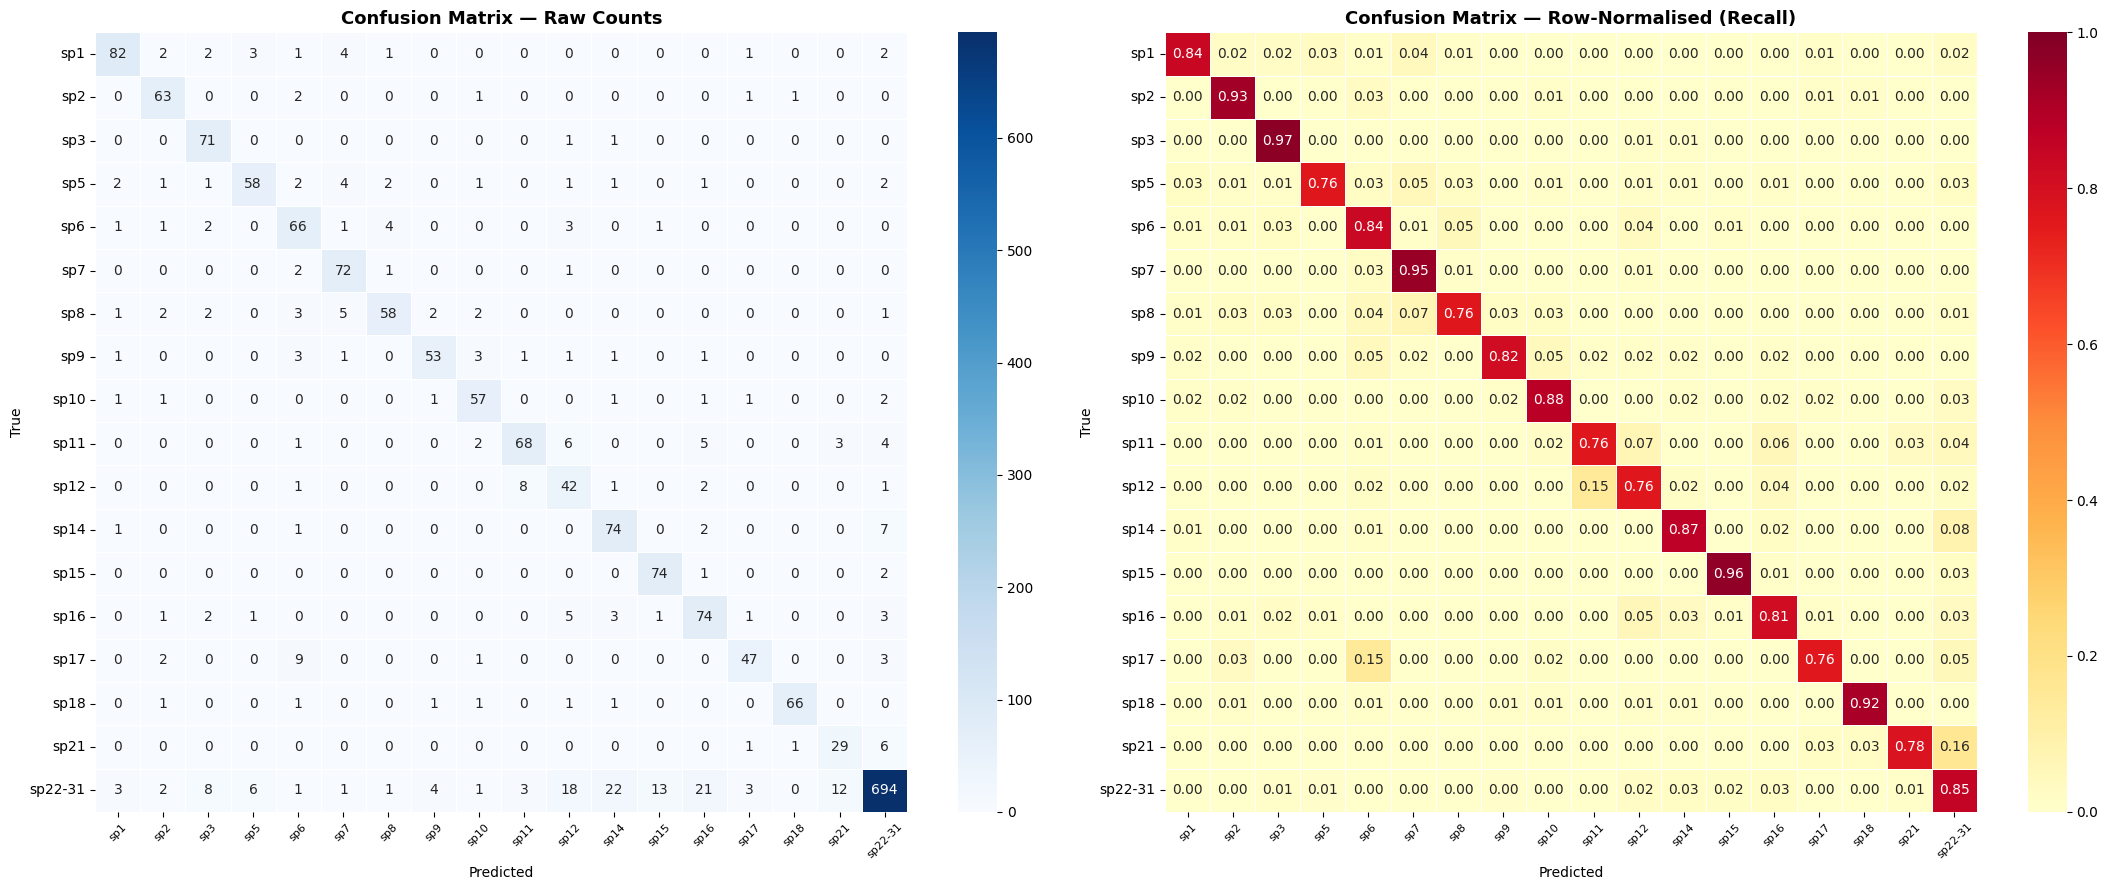

In [7]:
# Cell 6 — Evaluation (Test Split)
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

CHECKPOINT_PATH = "/workspace/ablation_runC_checkpoints/best_model.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SPECIES_LABEL_MAP = {
    1: "sp1",  2: "sp2",  3: "sp3",  5: "sp5",  6: "sp6",
    7: "sp7",  8: "sp8",  9: "sp9",  10: "sp10", 11: "sp11",
    12: "sp12", 14: "sp14", 15: "sp15", 16: "sp16",
    17: "sp17", 18: "sp18", 21: "sp21", 22: "sp22-31",
}
ALL_SPECIES   = sorted(SPECIES_LABEL_MAP.keys())
SPECIES_NAMES = [SPECIES_LABEL_MAP[s] for s in ALL_SPECIES]

test_ds     = HierarchicalInsectDataset(CSV_PATH, split="test", img_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

model_eval = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=False, feat_dim=512
).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt["model_state_dict"])
model_eval.eval()
print(f"Loaded epoch {ckpt['epoch']}  (saved val acc: {ckpt['val_species_acc']:.4f})")

all_preds   = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="TEST"):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}
        outputs  = model_eval(images)
        sp_pred  = predict_species_id(outputs).cpu().numpy()
        sp_tgt   = labels["species_id"].cpu().numpy()
        for pred, tgt in zip(sp_pred, sp_tgt):
            all_targets.append(merge_sp(tgt))
            all_preds.append(merge_sp(pred) if pred != -1 else -1)

all_targets = np.array(all_targets)
all_preds   = np.array(all_preds)

# Per-species table
print(f"\n{'='*80}\nTEST RESULTS — per species\n{'='*80}")
print(f"{'Species':<16} {'Acc':>7} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Correct':>9} {'Total':>7}")
print(f"{'-'*80}")

total_correct = total_samples = 0
per_species_acc = {}

for sid in ALL_SPECIES:
    mask  = all_targets == sid
    total = mask.sum()
    if total == 0:
        continue
    correct = (all_preds[mask] == sid).sum()
    acc     = correct / total
    y_true_bin = (all_targets == sid).astype(int)
    y_pred_bin = (all_preds   == sid).astype(int)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin,    y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin,        y_pred_bin, zero_division=0)
    flag = " ⚠️" if acc < 0.70 else ""
    print(f"{SPECIES_LABEL_MAP[sid]:<16} {acc:>7.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {correct:>9} {total:>7}{flag}")
    per_species_acc[sid] = acc
    total_correct += correct
    total_samples += total

overall_acc = total_correct / total_samples if total_samples else 0.0
print(f"{'-'*80}\n{'OVERALL':<16} {overall_acc:>7.4f}")

# Aggregate metrics
valid = all_preds != -1
y_true, y_pred = all_targets[valid], all_preds[valid]
labels_present = [s for s in ALL_SPECIES if s in y_true]

print(f"\n{'='*80}\nAGGREGATE METRICS\n{'='*80}")
print(f"  Overall Accuracy   : {overall_acc:.4f}")
print(f"  Balanced Accuracy  : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"  Macro F1           : {f1_score(y_true, y_pred, labels=labels_present, average='macro', zero_division=0):.4f}")
print(f"  Weighted F1        : {f1_score(y_true, y_pred, labels=labels_present, average='weighted', zero_division=0):.4f}")
print(f"  Cohen Kappa        : {cohen_kappa_score(y_true, y_pred):.4f}")
print(f"  MCC                : {matthews_corrcoef(y_true, y_pred):.4f}")

# Confusion matrix
cm      = confusion_matrix(y_true, y_pred, labels=labels_present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
target_names = [SPECIES_LABEL_MAP[s] for s in labels_present]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(cm,      ax=axes[0], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt="d",    cmap="Blues",   linewidths=0.4)
sns.heatmap(cm_norm, ax=axes[1], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt=".2f",  cmap="YlOrRd",  vmin=0, vmax=1, linewidths=0.4)
axes[0].set_title("Confusion Matrix — Raw Counts",           fontsize=13, fontweight="bold")
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall)", fontsize=13, fontweight="bold")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig("/workspace/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()